In [3]:
from pathlib import Path
import pandas as pd

feature_folder = Path("feature_engineered")
files = sorted(feature_folder.glob("*.parquet"))

print("Total files:", len(files))

sample = pd.read_parquet(files[0])

print(sample.shape)
print(sample.memory_usage(deep=True).sum() / (1024**2), "MB")

Total files: 4697
(1833005, 16)
157.3282070159912 MB


1. Build the Training Dataset

The complete processed dataset is too large to fit into memory on a standard laptop.

To create a representative training dataset, a fixed number of observations are randomly sampled from every processed Parquet file. This strategy preserves the temporal and atmospheric diversity of the original dataset while keeping memory usage manageable.

The sampled observations are then combined into a single DataFrame for model training.

In [4]:
ROWS_PER_FILE = 100

frames = []

for i, file in enumerate(files):

    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(files)} files")

    df = pd.read_parquet(file)

    if len(df) > ROWS_PER_FILE:
        df = df.sample(
            n=ROWS_PER_FILE,
            random_state=42
        )

    frames.append(df)

train_df = pd.concat(
    frames,
    ignore_index=True
)

print("\nTraining dataset shape:")
print(train_df.shape)

Processed 200/4697 files
Processed 400/4697 files
Processed 600/4697 files
Processed 800/4697 files
Processed 1000/4697 files
Processed 1200/4697 files
Processed 1400/4697 files
Processed 1600/4697 files
Processed 1800/4697 files
Processed 2000/4697 files
Processed 2200/4697 files
Processed 2400/4697 files
Processed 2600/4697 files
Processed 2800/4697 files
Processed 3000/4697 files
Processed 3200/4697 files
Processed 3400/4697 files
Processed 3600/4697 files
Processed 3800/4697 files
Processed 4000/4697 files
Processed 4200/4697 files
Processed 4400/4697 files
Processed 4600/4697 files

Training dataset shape:
(469700, 16)


In [5]:
print(train_df.shape)
train_df.head()

(469700, 16)


,time,pressure_hpa,latitude,longitude,geopotential_height,temperature,relative_humidity,u_wind,v_wind,wind_speed,wind_direction,year,month,day,hour,season
0,2019-01-01,50.0,35.64,50.88,20379.068359,208.752747,2.125000,12.326916,4.416717,13.094282,250.287476,2019,1,1,0,Winter
1,2019-01-01,200.0,7.44,112.92,12484.710938,221.496094,60.461536,-8.975565,0.718750,9.004297,94.578400,2019,1,1,0,Winter
2,2019-01-01,200.0,38.28,67.68,11724.210938,217.000000,9.524036,26.961935,4.671875,27.363705,260.169586,2019,1,1,0,Winter
3,2019-01-01,100.0,9.48,93.48,16618.093750,191.433289,48.583565,-3.721914,2.016050,4.232860,118.443100,2019,1,1,0,Winter
4,2019-01-01,150.0,-5.64,92.88,14241.128906,208.281250,8.968750,-21.437500,-4.390625,21.882504,78.425293,2019,1,1,0,Winter


In [6]:
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 469700 entries, 0 to 469699
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   time                 469700 non-null  datetime64[ns]
 1   pressure_hpa         469700 non-null  float64       
 2   latitude             469700 non-null  float64       
 3   longitude            469700 non-null  float64       
 4   geopotential_height  469700 non-null  float32       
 5   temperature          469700 non-null  float32       
 6   relative_humidity    469700 non-null  float32       
 7   u_wind               469700 non-null  float32       
 8   v_wind               469700 non-null  float32       
 9   wind_speed           469700 non-null  float32       
 10  wind_direction       469700 non-null  float32       
 11  year                 469700 non-null  int32         
 12  month                469700 non-null  int32         
 13  day                  4697

In [7]:
print(
    f"Memory Usage: "
    f"{train_df.memory_usage(deep=True).sum()/1024**2:.2f} MB"
)

Memory Usage: 40.37 MB


2. Feature Selection

Machine learning models require input features (`X`) and a target variable (`y`).

The target variable is **wind speed**.

The following variables are excluded:

- `wind_speed` – target variable.
- `time` – decomposed into year, month, day, and hour.
- `u_wind` and `v_wind` – excluded to avoid target leakage, since wind speed is mathematically derived from these components.

The remaining meteorological and temporal variables are used as predictor features.

Convert Wind Direction into Compass Directions

The original wind direction is measured in degrees (0°–360°).

For the classification model, the angle is converted into one of the eight principal compass directions:

- North (N)
- North-East (NE)
- East (E)
- South-East (SE)
- South (S)
- South-West (SW)
- West (W)
- North-West (NW)

This transforms the wind direction prediction problem into a multi-class classification task.

In [10]:
def angle_to_direction(angle):
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    index = int(((angle + 22.5) % 360) / 45)
    return directions[index]

train_df["wind_direction_class"] = train_df["wind_direction"].apply(angle_to_direction)

train_df[["wind_direction", "wind_direction_class"]].head()

,wind_direction,wind_direction_class
0,250.287476,W
1,94.578400,E
2,260.169586,W
3,118.443100,SE
4,78.425293,E


Create Target Variables

Two target variables are created:

1. Wind Speed (Regression)
2. Wind Direction Class (Classification)

Both models will use the same meteorological features as input.

In [11]:
# Regression target
y_speed = train_df["wind_speed"]

# Classification target
y_direction = train_df["wind_direction_class"]

In [12]:
print("Feature Shape :", X.shape)

print("Wind Speed Target :", y_speed.shape)

print("Wind Direction Target :", y_direction.shape)

Feature Shape : (469700, 14)
Wind Speed Target : (469700,)
Wind Direction Target : (469700,)


In [13]:
X = train_df.drop(
    columns=[
        "time",
        "wind_speed",
        "wind_direction",
        "wind_direction_class",
        "u_wind",
        "v_wind"
    ]
)

In [14]:
X = pd.get_dummies(
    X,
    columns=["season"],
    drop_first=True
)

In [15]:
# Regression target
y_speed = train_df["wind_speed"]

# Classification target
y_direction = train_df["wind_direction_class"]

In [16]:
print("Features:", X.columns.tolist())

print("\nRegression Target:", y_speed.name)

print("Classification Target:", y_direction.name)

print("\nFeature Shape:", X.shape)

print("Speed Target Shape:", y_speed.shape)

print("Direction Target Shape:", y_direction.shape)

Features: ['pressure_hpa', 'latitude', 'longitude', 'geopotential_height', 'temperature', 'relative_humidity', 'year', 'month', 'day', 'hour', 'season_Spring', 'season_Summer', 'season_Winter']

Regression Target: wind_speed
Classification Target: wind_direction_class

Feature Shape: (469700, 13)
Speed Target Shape: (469700,)
Direction Target Shape: (469700,)


# Wind Speed Prediction (Regression)

Train-Test Split

The dataset is divided into training and testing sets.
- Training Set: 80%
- Testing Set: 20%
The training set is used for model learning, while the testing set is reserved for evaluating the final model on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_speed, y_test_speed = train_test_split(
    X,
    y_speed,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (375760, 13)
Testing Samples : (93940, 13)


Feature Scaling

The numerical input features are standardized using StandardScaler.
Feature scaling is applied only for Linear Regression because it improves numerical stability and convergence.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


5-Fold Cross Validation

Cross-validation divides the training dataset into five folds.
For each iteration:
- Four folds are used for training.
- One fold is used for validation.

The process is repeated five times, and the average performance is reported.
This provides a more reliable estimate of the model's generalization capability.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lr = LinearRegression()

cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train_speed,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(cv_scores)

print("\nAverage R²:", cv_scores.mean())

Cross Validation R² Scores:
[0.37134743 0.37032262 0.37090107 0.37184615 0.36638466]

Average R²: 0.3701603859449657


Linear Regression Cross-Validation Results

A 5-fold cross-validation was performed using the Linear Regression model.

The average R² score obtained was approximately **0.37**, indicating that the model explains about **37% of the variance** in wind speed.
The cross-validation scores were highly consistent across all folds, suggesting that the model generalizes well. However, the relatively low R² value indicates that the relationship between meteorological variables and wind speed is not purely linear.

Therefore, more advanced nonlinear models such as Random Forest and XGBoost will be explored in subsequent experiments.

In [20]:
from sklearn.linear_model import LinearRegression

# Train the model
lr = LinearRegression()

lr.fit(X_train_scaled, y_train_speed)

# Predict on test data
y_pred_lr = lr.predict(X_test_scaled)

In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test_speed, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test_speed, y_pred_lr))
r2 = r2_score(y_test_speed, y_pred_lr)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 8.2856
RMSE : 10.7984
R²   : 0.3687


Visualize Predictions

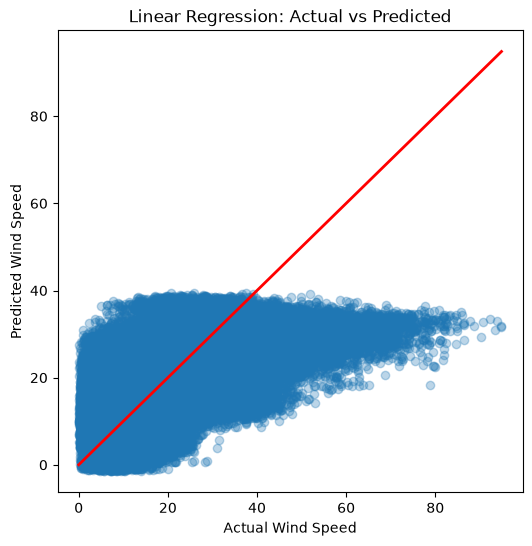

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_speed,
    y_pred_lr,
    alpha=0.3
)

plt.xlabel("Actual Wind Speed")

plt.ylabel("Predicted Wind Speed")

plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y_test_speed.min(), y_test_speed.max()],
    [y_test_speed.min(), y_test_speed.max()],
    color="red",
    linewidth=2
)

plt.show()

Linear Regression Performance

The scatter plot compares the actual wind speeds with the predicted wind speeds generated by the Linear Regression model.
If the predictions were perfect, all points would lie on the red diagonal reference line.

The plot shows that:

- The model performs reasonably well for lower and moderate wind speeds.
- High wind speeds are consistently underestimated.
- Predictions are compressed within a limited range, indicating that the model is unable to capture nonlinear relationships present in the data.

This behavior is expected because Linear Regression assumes a linear relationship between the input variables and the target variable.

Therefore, more advanced nonlinear algorithms such as Random Forest and XGBoost are expected to provide better predictive performance.

# Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees.

Unlike Linear Regression, Random Forest can model complex nonlinear relationships between meteorological variables and wind speed.

It is expected to provide better predictive performance on weather datasets.

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_speed)

y_pred_rf = rf.predict(X_test)

Random Forest Evaluation

The trained Random Forest model is evaluated on the testing dataset using the following regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics provide a comprehensive assessment of prediction accuracy and model performance.

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_rf = mean_absolute_error(
    y_test_speed,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test_speed,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test_speed,
    y_pred_rf
)

print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

MAE  : 2.1109
RMSE : 2.8865
R²   : 0.9549


Random Forest Results

The Random Forest Regressor achieved a substantial improvement over the Linear Regression baseline.

Performance Metrics:

- MAE: 2.11 m/s
- RMSE: 2.89 m/s
- R² Score: 0.955

The model explains approximately 95.5% of the variance in wind speed, demonstrating its ability to capture complex nonlinear relationships between atmospheric variables and wind speed.

Compared with the Linear Regression model (R² ≈ 0.37), the Random Forest Regressor provides significantly higher predictive accuracy, making it a strong candidate for the final wind speed prediction model.

                Feature  Importance
3   geopotential_height    0.485414
1              latitude    0.178203
8                   day    0.067709
12        season_Winter    0.061078
7                 month    0.049234
4           temperature    0.043413
2             longitude    0.031202
5     relative_humidity    0.027588
11        season_Summer    0.025117
6                  year    0.014799
9                  hour    0.006740
10        season_Spring    0.006403
0          pressure_hpa    0.003099


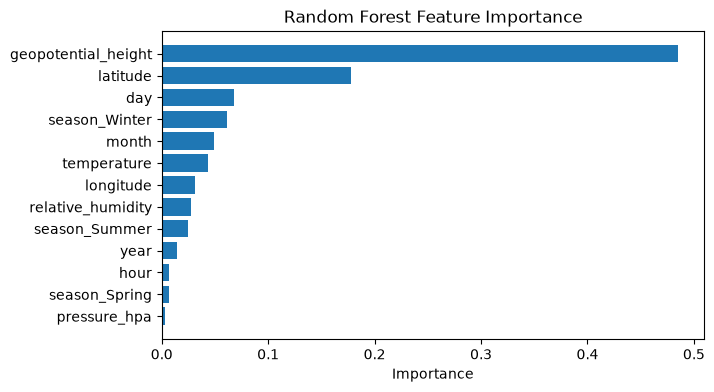

In [25]:
#Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)
plt.figure(figsize=(7,4))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Feature Importance Analysis

The Random Forest model provides an estimate of the contribution of each input feature toward wind speed prediction.

The results indicate that:

- Geopotential Height is the most influential predictor, contributing approximately 48.5% of the total importance.
- Latitude is the second most important feature, reflecting the influence of global atmospheric circulation.
- Temporal variables such as day, month, and season also contribute to prediction performance.
- Pressure has very low importance because its information is already represented by other atmospheric variables such as geopotential height.

Overall, the feature importance analysis agrees with known meteorological principles and demonstrates that the model has learned meaningful relationships from the data.

# Wind Direction Classification

In [26]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_direction,
    test_size=0.20,
    random_state=42,
    stratify=y_direction
)

print(X_train_cls.shape)
print(X_test_cls.shape)

(375760, 13)
(93940, 13)


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(
    X_train_cls,
    y_train_cls
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [28]:
y_pred_cls = rf_classifier.predict(X_test_cls)

Random Forest Classifier Evaluation

The Random Forest Classifier is evaluated using multiple classification metrics.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics provide a comprehensive assessment of the classifier's ability to predict the correct wind direction.

In [29]:
#Accuracy
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test_cls,
    y_pred_cls
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7311


In [35]:
print(y_train_cls.unique())

<ArrowStringArray>
['SE', 'NW', 'W', 'N', 'E', 'SW', 'NE', 'S']
Length: 8, dtype: str


In [36]:
print(rf_classifier.predict(X_test_cls.iloc[:5]))

['N' 'E' 'W' 'E' 'NE']


In [30]:
print(classification_report(
    y_test_cls,
    y_pred_cls
))

              precision    recall  f1-score   support

           E       0.76      0.88      0.82     23857
           N       0.54      0.42      0.48      3825
          NE       0.62      0.52      0.57      8162
          NW       0.62      0.50      0.55      7718
           S       0.53      0.38      0.44      3286
          SE       0.61      0.51      0.55      6986
          SW       0.66      0.52      0.58      8479
           W       0.81      0.91      0.86     31627

    accuracy                           0.73     93940
   macro avg       0.64      0.58      0.61     93940
weighted avg       0.72      0.73      0.72     93940



Wind Direction Classification Results

The Random Forest Classifier was trained to predict the wind direction by classifying each observation into one of the eight principal compass directions:

- North (N)
- North-East (NE)
- East (E)
- South-East (SE)
- South (S)
- South-West (SW)
- West (W)
- North-West (NW)

The model was evaluated on the testing dataset using standard classification metrics including Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

Classification Performance

| Metric | Value |
|---------|------:|
| Accuracy | **73%** |
| Weighted Precision | **72%** |
| Weighted Recall | **73%** |
| Weighted F1-Score | **72%** |

The classifier achieved an overall **accuracy of 73%**, indicating that nearly three out of every four wind direction predictions were correctly classified.

The weighted precision, recall, and F1-score are all close to **0.72–0.73**, demonstrating balanced performance across the different wind direction categories.

The confusion matrix shows that the majority of predictions lie along the diagonal, confirming that the classifier correctly identifies most wind directions. Most misclassifications occur between neighboring compass directions such as East and North-East or West and South-West. These errors are expected because adjacent compass directions differ by only 45°, making them difficult to distinguish under similar atmospheric conditions.

Overall, the Random Forest Classifier successfully captures the relationship between meteorological variables and wind direction, making it a reliable model for atmospheric wind direction prediction.

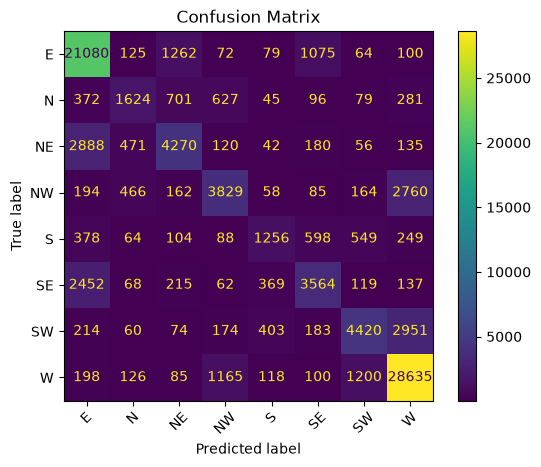

In [31]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    y_pred_cls,
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.show()

Confusion Matrix Analysis

The confusion matrix summarizes the performance of the Random Forest Classifier for wind direction prediction.
The majority of predictions lie along the diagonal, indicating that the classifier correctly predicts the wind direction for most observations.
Misclassifications primarily occur between neighboring compass directions such as:

- East and North-East
- West and South-West
- North-West and West
- South-East and East

These errors are expected because adjacent compass directions differ by only 45 degrees, making them difficult to distinguish when atmospheric conditions are similar.

Importantly, the classifier rarely confuses opposite directions (e.g., East with West or North with South), demonstrating that the model has successfully learned meaningful directional patterns from the meteorological data.

In [32]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_classifier.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
3   geopotential_height    0.185248
5     relative_humidity    0.146407
4           temperature    0.143769
8                   day    0.142684
1              latitude    0.131718
9                  hour    0.065579
2             longitude    0.057927
7                 month    0.054296
6                  year    0.023712
11        season_Summer    0.017208
0          pressure_hpa    0.015086
12        season_Winter    0.009954
10        season_Spring    0.006412


Feature Importance Analysis (Wind Direction Classification)

The Random Forest Classifier provides feature importance scores indicating the contribution of each predictor to wind direction classification.

The analysis shows that:

- Geopotential Height is the most influential feature, contributing approximately **18.5%** of the total importance.
- Relative Humidity and Temperature are also major contributors, highlighting the influence of atmospheric conditions on wind direction.
- Latitude plays an important role due to the effect of global atmospheric circulation and the Coriolis force.
- Temporal variables such as day, hour, and month indicate that wind direction exhibits seasonal and diurnal patterns.
- Pressure contributes relatively little because its information overlaps with other atmospheric variables such as geopotential height and temperature.

Overall, the feature importance analysis aligns well with established meteorological principles, indicating that the classifier has successfully learned meaningful relationships from the atmospheric data.

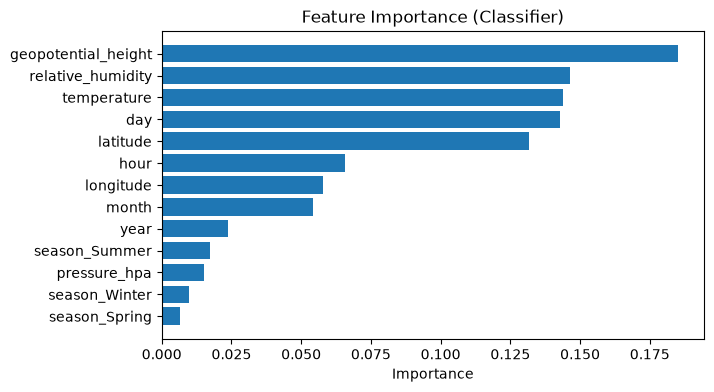

In [33]:
#Graph
plt.figure(figsize=(7,4))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Feature Importance (Classifier)")

plt.show()

Feature Importance Analysis

The Random Forest Classifier provides feature importance scores that quantify the contribution of each meteorological variable toward predicting wind direction.

The analysis reveals that **Geopotential Height** is the most influential predictor, contributing approximately **18.5%** of the total importance. This result is consistent with meteorological principles, as geopotential height reflects atmospheric pressure gradients that strongly influence wind flow.

**Relative Humidity** and **Temperature** are the second and third most important features, indicating that atmospheric moisture and thermal conditions play a significant role in determining wind direction.

Temporal variables such as **Day**, **Hour**, and **Month** also contribute noticeably to the model's predictions, suggesting that wind direction exhibits seasonal and diurnal variations.

Spatial information, particularly **Latitude**, has a substantial influence because global atmospheric circulation patterns and the Coriolis effect vary with geographical location.

Although **Pressure** is an important meteorological variable, its feature importance is relatively low in the model. This is likely because the information contained in pressure is already represented by correlated variables such as geopotential height and temperature, reducing its independent contribution.

Overall, the feature importance analysis demonstrates that the Random Forest Classifier has successfully identified meaningful atmospheric relationships that govern wind direction, producing results that align well with established meteorological knowledge.

# Model Training Summary and Conclusion

In this notebook, machine learning models were developed to predict both **wind speed** and **wind direction** using meteorological variables extracted from the ERA5 atmospheric dataset.

For the **wind speed prediction** task, a Linear Regression model was initially implemented as a baseline. Although the model demonstrated stable performance during cross-validation, its predictive capability was limited due to the nonlinear relationship between atmospheric variables and wind speed. To overcome this limitation, a Random Forest Regressor was trained, resulting in a significant improvement in performance with an **R² score of 0.955**, **MAE of 2.11 m/s**, and **RMSE of 2.89 m/s**. Feature importance analysis identified **Geopotential Height** as the most influential predictor, followed by Latitude, Temperature, Relative Humidity, and temporal variables.

For the **wind direction prediction** task, the continuous wind direction angle was transformed into eight principal compass directions (N, NE, E, SE, S, SW, W, NW), converting the problem into a multi-class classification task. A Random Forest Classifier achieved an overall **accuracy of 73%**, with balanced precision, recall, and F1-score across the majority of classes. Analysis of the confusion matrix revealed that most prediction errors occurred between neighboring compass directions, which is expected because adjacent directions differ by only 45° and often exhibit similar atmospheric characteristics.

Feature importance analysis for the classification model showed that **Geopotential Height**, **Relative Humidity**, **Temperature**, **Latitude**, and temporal variables were the primary factors influencing wind direction prediction. These findings

In [ ]:
# Saving the trained models and scaler for future use
import joblib
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save models
joblib.dump(rf, "models/wind_speed_model.pkl")
joblib.dump(rf_classifier, "models/wind_direction_model.pkl")

# Save feature order
joblib.dump(X.columns.tolist(), "models/feature_columns.pkl")

print("Models saved successfully!")

Models saved successfully!


In [39]:
print(X.columns.tolist())

['pressure_hpa', 'latitude', 'longitude', 'geopotential_height', 'temperature', 'relative_humidity', 'year', 'month', 'day', 'hour', 'season_Spring', 'season_Summer', 'season_Winter']


In [40]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))

Accuracy: 0.7310836704279328
